In [1]:
!pip install lightgbm xgboost scikit-learn s3fs pyarrow pandas matplotlib seaborn s3fs numpy


[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


In [2]:
import os
import time
import warnings
from typing import Dict, List, Tuple

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import s3fs
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    auc,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
import lightgbm as lgb
import xgboost as xgb
from IPython.display import display

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

# Configura as credenciais de rede que estão expostas no seu docker-compose
fs = s3fs.S3FileSystem(
    key="minioadmin",
    secret="minioadmin",
    client_kwargs={"endpoint_url": "http://localhost:9000"}
)

# --- Configuração reproduzível ---
RANDOM_STATE = 42
TEST_SIZE = 0.20
FULL_DATASET_ROWS = 307_511

# Hiperparâmetros dos boosters — n_estimators=300 (máximo ROC-AUC no sweep, seção 9.4)
BOOSTER_N_ESTIMATORS = 300
LGBM_NUM_LEAVES = 31
LGBM_LEARNING_RATE = 0.05

ABT_PATH = 's3://abt/abt_train.parquet'
# ABT_PATH = 'abt_train.parquet'  # ajuste se o Parquet estiver em outra pasta

DROP_COLS = ['SK_ID_CURR', 'TARGET']

print('Setup modelagem OK.')
print(f'ABT: {ABT_PATH} | seed={RANDOM_STATE} | holdout={TEST_SIZE:.0%}')

Setup modelagem OK.
ABT: s3://abt/abt_train.parquet | seed=42 | holdout=20%


In [3]:
def qa_abt_load(df: pd.DataFrame, expected_rows: int = FULL_DATASET_ROWS) -> None:
    print('[QA] Carga abt_train')
    n = len(df)
    if n == expected_rows:
        print(f' -> [PASS] Volumetria integral: {n:,} linhas')
    else:
        print(f' -> [ATENÇÃO] {n:,} linhas (esperado {expected_rows:,}) — ABT pode estar incompleta')

    dup = df.duplicated(subset=['SK_ID_CURR']).sum()
    print(f' -> [{"PASS" if dup == 0 else "FAIL"}] SK_ID_CURR único (dup={dup})')

    if 'TARGET' not in df.columns:
        raise ValueError('TARGET ausente na ABT')
    rate = df['TARGET'].mean()
    ok_rate = 0.05 < rate < 0.12
    print(f' -> [{"PASS" if ok_rate else "FAIL"}] Taxa TARGET = {rate:.2%}')

    inf_n = np.isinf(df.select_dtypes(include=[np.number])).sum().sum()
    print(f' -> [{"PASS" if inf_n == 0 else "FAIL"}] Sem inf ({inf_n})')
    print('---\n')


with fs.open(ABT_PATH, 'rb') as f:
    abt = pd.read_parquet(f, engine='pyarrow')
    
print(f'Carregado: {abt.shape[0]:,} linhas x {abt.shape[1]} colunas')
qa_abt_load(abt)

target_dist = abt['TARGET'].value_counts(normalize=True).rename({0: 'Pagou (0)', 1: 'Inadimplente (1)'})
print('Distribuição TARGET:')
display((target_dist * 100).round(2).to_frame('percentual'))

Carregado: 307,511 linhas x 198 colunas
[QA] Carga abt_train
 -> [PASS] Volumetria integral: 307,511 linhas
 -> [PASS] SK_ID_CURR único (dup=0)
 -> [PASS] Taxa TARGET = 8.07%
 -> [PASS] Sem inf (0)
---

Distribuição TARGET:


,percentual
TARGET,
Pagou (0),91.93
Inadimplente (1),8.07


In [4]:
def split_features_target(df: pd.DataFrame) -> Tuple[pd.DataFrame, pd.Series]:
    y = df['TARGET'].astype(int)
    X = df.drop(columns=[c for c in DROP_COLS if c in df.columns])
    return X, y


X, y = split_features_target(abt)

numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = X.select_dtypes(include=['object', 'string', 'category']).columns.tolist()

print(f'Features totais: {X.shape[1]}')
print(f'  Numéricas: {len(numeric_cols)} | Categóricas: {len(categorical_cols)}')
print(f'Categóricas: {categorical_cols}')

null_pct = (X.isna().mean() * 100).sort_values(ascending=False)
print('\nTop 10 features com mais % de nulos:')
display(null_pct.head(10).round(2).to_frame('% nulos'))

Features totais: 196
  Numéricas: 180 | Categóricas: 16
Categóricas: ['NAME_CONTRACT_TYPE', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'NAME_TYPE_SUITE', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'OCCUPATION_TYPE', 'WEEKDAY_APPR_PROCESS_START', 'ORGANIZATION_TYPE', 'FONDKAPREMONT_MODE', 'HOUSETYPE_MODE', 'WALLSMATERIAL_MODE', 'EMERGENCYSTATE_MODE']

Top 10 features com mais % de nulos:


,% nulos
CC_UTILIZATION_MEAN,72.02
CC_UTILIZATION_MAX,72.02
CC_SK_DPD_MEAN,71.74
CC_CNT_MONTHS,71.74
CC_SK_DPD_MAX,71.74
CC_AMT_LIMIT_MEAN,71.74
CC_RATE_DPD,71.74
CC_CNT_DPD_GT0,71.74
CC_AMT_BALANCE_MEAN,71.74
CC_AMT_BALANCE_MAX,71.74


In [5]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y,
)

scale_pos_weight = (y_train == 0).sum() / max((y_train == 1).sum(), 1)

print(f'Treino: {len(X_train):,} | Validação: {len(X_val):,}')
print(f'Taxa TARGET treino: {y_train.mean():.2%} | validação: {y_val.mean():.2%}')
print(f'scale_pos_weight (boosters): {scale_pos_weight:.2f}')

Treino: 246,008 | Validação: 61,503
Taxa TARGET treino: 8.07% | validação: 8.07%
scale_pos_weight (boosters): 11.39


In [6]:
def prepare_boosters_data(X_tr: pd.DataFrame, X_te: pd.DataFrame) -> Tuple[pd.DataFrame, pd.DataFrame]:
    X_tr_b = X_tr.copy()
    X_te_b = X_te.copy()
    for col in categorical_cols:
        X_tr_b[col] = X_tr_b[col].astype('category')
        X_te_b[col] = pd.Categorical(X_te_b[col], categories=X_tr_b[col].cat.categories)
    return X_tr_b, X_te_b


X_train_boost, X_val_boost = prepare_boosters_data(X_train, X_val)

print('Dados preparados para boosters (LightGBM com categorias tipadas)')

Dados preparados para boosters (LightGBM com categorias tipadas)


In [7]:
print('\n[TREINO] LightGBM')
t0 = time.perf_counter()
lgbm_model = lgb.LGBMClassifier(
    n_estimators=BOOSTER_N_ESTIMATORS,
    learning_rate=LGBM_LEARNING_RATE,
    num_leaves=LGBM_NUM_LEAVES,
    max_depth=-1,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=-1,
    categorical_feature=categorical_cols,
)
lgbm_model.fit(X_train_boost, y_train)
tempo_treino = time.perf_counter() - t0

proba_lgbm = lgbm_model.predict_proba(X_val_boost)[:, 1]
y_pred_lgbm = (proba_lgbm >= 0.5).astype(int)

roc_auc_lgbm = roc_auc_score(y_val, proba_lgbm)

print(f'  ROC-AUC (validação): {roc_auc_lgbm:.4f}')
print(f'  Tempo de treino: {tempo_treino:.1f}s')
print(f'  Modelo salvo em memória para exportação')


[TREINO] LightGBM
  ROC-AUC (validação): 0.7757
  Tempo de treino: 17.4s
  Modelo salvo em memória para exportação


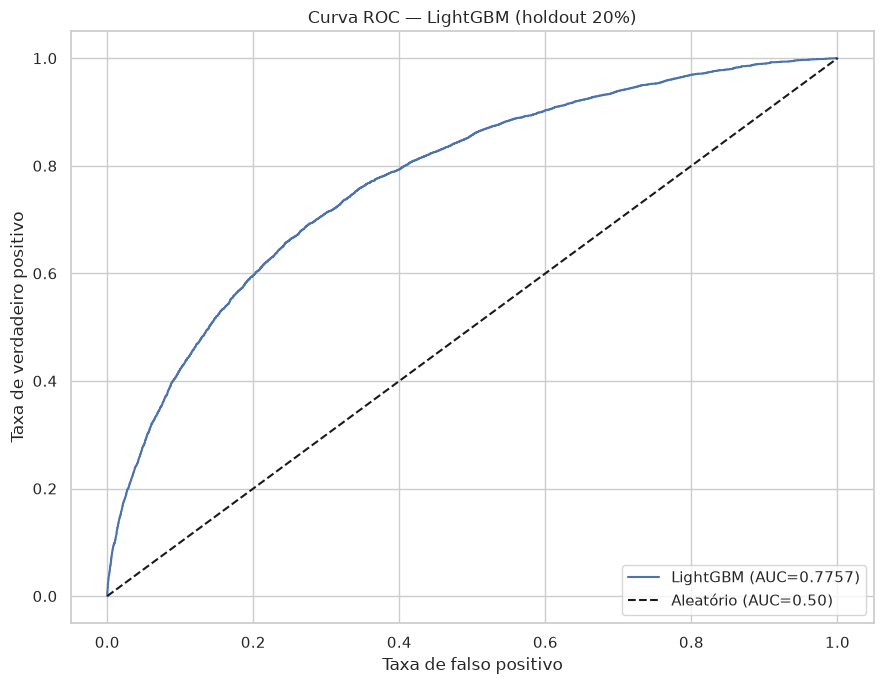

ROC-AUC LightGBM: 0.7757


In [8]:
fig, ax = plt.subplots(figsize=(9, 7))
fpr, tpr, _ = roc_curve(y_val, proba_lgbm)
ax.plot(fpr, tpr, label=f"LightGBM (AUC={roc_auc_lgbm:.4f})")
ax.plot([0, 1], [0, 1], 'k--', label='Aleatório (AUC=0.50)')
ax.set_xlabel('Taxa de falso positivo')
ax.set_ylabel('Taxa de verdadeiro positivo')
ax.set_title('Curva ROC — LightGBM (holdout 20%)')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

print(f'ROC-AUC LightGBM: {roc_auc_lgbm:.4f}')

## Nota sobre threshold exploratório

Neste notebook de exploração, algumas células usam `threshold = 0.5` para comparação técnica padrão entre modelos.

O threshold operacional de produção para decisão de negócio **não é este**: ele é carregado de `Model/model_config.yaml` em `business_rules.business_threshold` (atualmente `0.08`) e aplicado pelos scripts de runtime (`scripts/train.py` e `scripts/predict.py`).


[CLASSIFICAÇÃO] Threshold = 0.5
                  precision    recall  f1-score   support

       Pagou (0)       0.96      0.77      0.85     56538
Inadimplente (1)       0.19      0.64      0.30      4965

        accuracy                           0.76     61503
       macro avg       0.58      0.70      0.58     61503
    weighted avg       0.90      0.76      0.81     61503



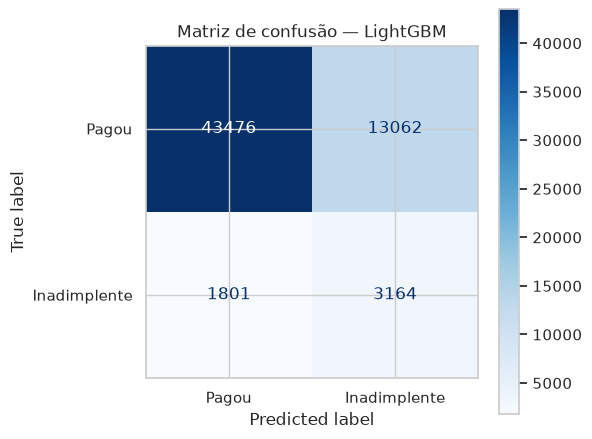

In [9]:
print('\n[CLASSIFICAÇÃO] Threshold = 0.5')
print(classification_report(y_val, y_pred_lgbm, target_names=['Pagou (0)', 'Inadimplente (1)']))

fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_val, y_pred_lgbm)
ConfusionMatrixDisplay(cm, display_labels=['Pagou', 'Inadimplente']).plot(ax=ax, cmap='Blues')
ax.set_title('Matriz de confusão — LightGBM')
plt.tight_layout()
plt.show()


Top 20 features — LightGBM


,feature,importance
38,ORGANIZATION_TYPE,2306
26,OCCUPATION_TYPE,477
41,EXT_SOURCE_3,434
39,EXT_SOURCE_1,428
122,EXT_SOURCE_MEAN,426
15,DAYS_BIRTH,391
7,AMT_ANNUITY,350
40,EXT_SOURCE_2,349
178,PREV_DAYS_DECISION_MIN,339
6,AMT_CREDIT,323


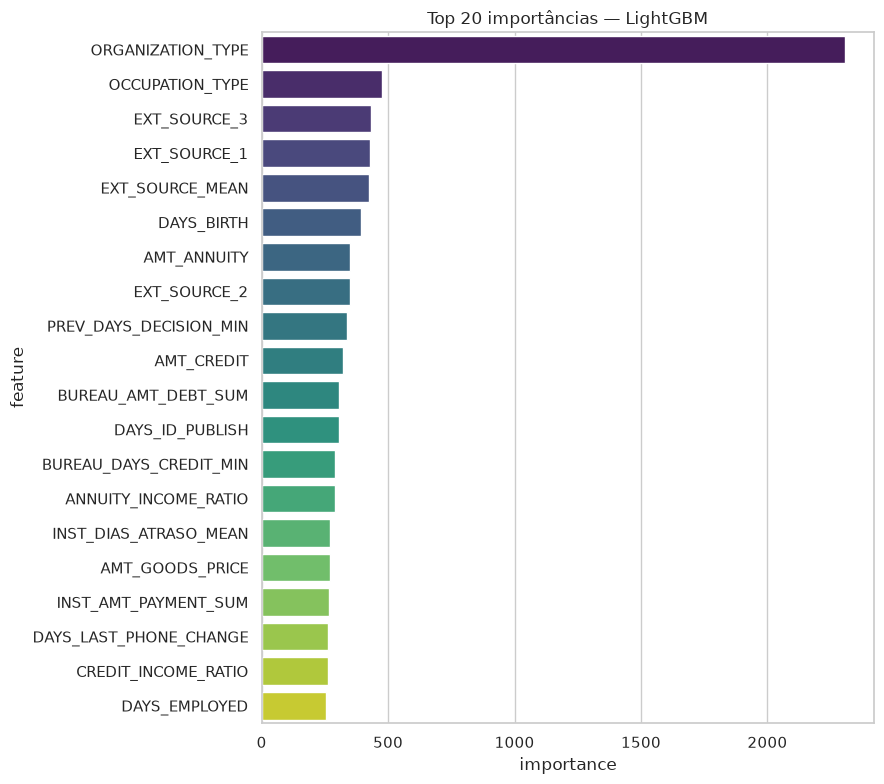

In [10]:
imp = lgbm_model.feature_importances_
feat_names = X_train_boost.columns.tolist()
imp_df = pd.DataFrame({'feature': feat_names, 'importance': imp}).sort_values('importance', ascending=False)

print(f'\nTop 20 features — LightGBM')
display(imp_df.head(20))

fig, ax = plt.subplots(figsize=(9, 8))
top = imp_df.head(20)
sns.barplot(data=top, y='feature', x='importance', ax=ax, palette='viridis')
ax.set_title('Top 20 importâncias — LightGBM')
plt.tight_layout()
plt.show()

In [ ]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

lgbm_cv = lgb.LGBMClassifier(
    n_estimators=BOOSTER_N_ESTIMATORS,
    learning_rate=LGBM_LEARNING_RATE,
    num_leaves=LGBM_NUM_LEAVES,
    scale_pos_weight=scale_pos_weight,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=-1,
    categorical_feature=categorical_cols,
)

cv_scores = cross_val_score(
    lgbm_cv,
    X_train_boost,
    y_train,
    cv=cv,
    scoring='roc_auc',
    n_jobs=-1,
)
print(f'\nLightGBM 5-fold CV AUC: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})')
print('Scores por fold:', [round(s, 4) for s in cv_scores])

In [12]:
param_grid = [
    {'num_leaves': 31, 'learning_rate': 0.05},
    {'num_leaves': 63, 'learning_rate': 0.05},
    {'num_leaves': 31, 'learning_rate': 0.03},
]

best_tune_auc = -1
best_tune_params = None

print('\n[TUNING] Grid pequeno de hiperparâmetros:')
for params in param_grid:
    m = lgb.LGBMClassifier(
        n_estimators=BOOSTER_N_ESTIMATORS,
        max_depth=-1,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=scale_pos_weight,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbose=-1,
        categorical_feature=categorical_cols,
        **params,
    )
    m.fit(X_train_boost, y_train)
    p = m.predict_proba(X_val_boost)[:, 1]
    s = roc_auc_score(y_val, p)
    print(f"  params={params} -> AUC={s:.4f}")
    if s > best_tune_auc:
        best_tune_auc = s
        best_tune_params = params

print(f'\nMelhor grid: {best_tune_params} | AUC={best_tune_auc:.4f}')


[TUNING] Grid pequeno de hiperparâmetros:
  params={'num_leaves': 31, 'learning_rate': 0.05} -> AUC=0.7760
  params={'num_leaves': 63, 'learning_rate': 0.05} -> AUC=0.7757
  params={'num_leaves': 31, 'learning_rate': 0.03} -> AUC=0.7751

Melhor grid: {'num_leaves': 31, 'learning_rate': 0.05} | AUC=0.7760



[SWEEP] Custo × benefício — n_estimators:
  n_estimators=100 -> AUC=0.7721 | tempo=8.6s
  n_estimators=200 -> AUC=0.7754 | tempo=15.0s
  n_estimators=300 -> AUC=0.7757 | tempo=15.0s
  n_estimators=500 -> AUC=0.7742 | tempo=23.4s
  n_estimators=800 -> AUC=0.7697 | tempo=36.9s

Tabela custo × benefício:


,n_estimators,roc_auc,tempo_treino_s,ganho_auc,tempo_extra_s,seg_por_0.001_auc
0,100,0.7721,8.6155,0.0000,8.6155,NaN
1,200,0.7754,15.0273,0.0033,6.4118,1.9379
2,300,0.7757,14.9643,0.0002,-0.0630,-0.2685
3,500,0.7742,23.3986,-0.0015,8.4342,NaN
4,800,0.7697,36.8861,-0.0045,13.4876,NaN



[REFERÊNCIA] n_estimators=300 — AUC máximo = 0.7757 em 15.0s


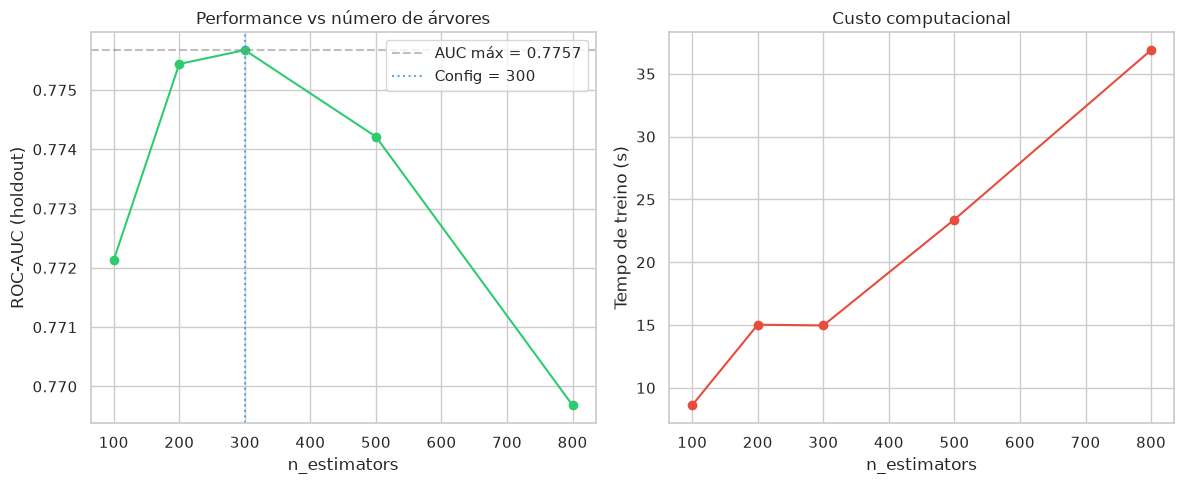

In [13]:
def train_lgbm_with_n_trees(n_estimators: int) -> Tuple[lgb.LGBMClassifier, float, float]:
    t0 = time.perf_counter()
    model = lgb.LGBMClassifier(
        n_estimators=n_estimators,
        learning_rate=LGBM_LEARNING_RATE,
        num_leaves=LGBM_NUM_LEAVES,
        max_depth=-1,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=scale_pos_weight,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbose=-1,
        categorical_feature=categorical_cols,
    )
    model.fit(X_train_boost, y_train)
    elapsed = time.perf_counter() - t0
    proba = model.predict_proba(X_val_boost)[:, 1]
    auc_score = roc_auc_score(y_val, proba)
    return model, auc_score, elapsed


N_ESTIMATORS_GRID = [100, 200, 300, 500, 800]
sweep_rows = []

print('\n[SWEEP] Custo × benefício — n_estimators:')
for n_trees in N_ESTIMATORS_GRID:
    _, auc_s, elapsed = train_lgbm_with_n_trees(n_trees)
    sweep_rows.append({
        'n_estimators': n_trees,
        'roc_auc': auc_s,
        'tempo_treino_s': elapsed,
    })
    print(f'  n_estimators={n_trees} -> AUC={auc_s:.4f} | tempo={elapsed:.1f}s')

sweep_df = pd.DataFrame(sweep_rows).sort_values('n_estimators').reset_index(drop=True)
sweep_df['ganho_auc'] = sweep_df['roc_auc'].diff().fillna(0)
sweep_df['tempo_extra_s'] = sweep_df['tempo_treino_s'].diff().fillna(sweep_df['tempo_treino_s'])
sweep_df['seg_por_0.001_auc'] = np.where(
    sweep_df['ganho_auc'] > 0,
    sweep_df['tempo_extra_s'] / (sweep_df['ganho_auc'] * 1000),
    np.nan,
)

print('\nTabela custo × benefício:')
display(sweep_df.round(4))

best_row = sweep_df.loc[sweep_df['roc_auc'].idxmax()]
print(f"\n[REFERÊNCIA] n_estimators={int(best_row['n_estimators'])} — AUC máximo = {best_row['roc_auc']:.4f} em {best_row['tempo_treino_s']:.1f}s")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(sweep_df['n_estimators'], sweep_df['roc_auc'], marker='o', color='#2ecc71')
axes[0].axhline(best_row['roc_auc'], color='gray', linestyle='--', alpha=0.5, label=f'AUC máx = {best_row["roc_auc"]:.4f}')
axes[0].axvline(BOOSTER_N_ESTIMATORS, color='#3498db', linestyle=':', alpha=0.8, label=f'Config = {BOOSTER_N_ESTIMATORS}')
axes[0].set_xlabel('n_estimators')
axes[0].set_ylabel('ROC-AUC (holdout)')
axes[0].set_title('Performance vs número de árvores')
axes[0].legend()

axes[1].plot(sweep_df['n_estimators'], sweep_df['tempo_treino_s'], marker='o', color='#e74c3c')
axes[1].set_xlabel('n_estimators')
axes[1].set_ylabel('Tempo de treino (s)')
axes[1].set_title('Custo computacional')

plt.tight_layout()
plt.show()

In [18]:
import pickle
from datetime import datetime

DATE = datetime.today().strftime('%Y%m%d')
MODEL_NAME = f'lightgbm_hcdr_{DATE}.pkl'
ARTIFACTS_PATH = f's3://artifacts/{MODEL_NAME}'  # habilite para salvar em bucket S3/MinIO
# ARTIFACTS_PATH = MODEL_NAME  # salva o pickle na raiz do projeto (local, para testes)

print(f'\n[EXPORTAÇÃO] Salvando modelo LightGBM em pickle...')
print(f'  Destino: {ARTIFACTS_PATH}')

model_bytes = pickle.dumps(lgbm_model)
print(f'  Tamanho do arquivo: {len(model_bytes) / (1024**2):.2f} MB')

try:
    # Se o caminho for s3://, usa o filesystem configurado (MinIO). Caso contrário, grava localmente.
    if isinstance(ARTIFACTS_PATH, str) and ARTIFACTS_PATH.startswith('s3://'):
        with fs.open(ARTIFACTS_PATH, 'wb') as f:
            f.write(model_bytes)
    else:
        with open(ARTIFACTS_PATH, 'wb') as f:
            f.write(model_bytes)
    print(f'  ✓ Modelo salvo com sucesso!')
except Exception as e:
    print(f'  ✗ Erro ao salvar: {e}')

print(f'\nResumo Final:')
print(f'  Modelo: LightGBM')
print(f'  ROC-AUC (validação holdout): {roc_auc_lgbm:.4f}')
print(f'  Tempo de treino: {tempo_treino:.1f}s')
print(f'  Features: {X_train_boost.shape[1]}')
print(f'  Linhas de treino: {X_train_boost.shape[0]:,}')
print(f'  Arquivo exportado: {ARTIFACTS_PATH}')


[EXPORTAÇÃO] Salvando modelo LightGBM em pickle...
  Destino: s3://artifacts/lightgbm_hcdr_20260705.pkl
  Tamanho do arquivo: 2.03 MB
  ✓ Modelo salvo com sucesso!

Resumo Final:
  Modelo: LightGBM
  ROC-AUC (validação holdout): 0.7757
  Tempo de treino: 17.4s
  Features: 196
  Linhas de treino: 246,008
  Arquivo exportado: s3://artifacts/lightgbm_hcdr_20260705.pkl
